# Transformada Inversa: Distribución Exponencial

Este notebook genera 200 números aleatorios utilizando dos fuentes:
1. **random.org:** Números verdaderamente aleatorios basados en ruido atmosférico.
2. **Pseudoaleatorios:** Generados mediante un algoritmo en Python con una semilla fija.

El objetivo es aplicar el método de la transformada inversa para generar variables aleatorias que sigan una distribución exponencial con parámetro $\lambda = 1.5$.

## Fórmulas Matemáticas

La Función de Densidad de Probabilidad (PDF) de una distribución exponencial es:
$$f(x) = \lambda e^{-\lambda x}, \quad \text{para } x \ge 0$$

Para encontrar la transformada inversa, primero calculamos la Función de Distribución Acumulada (CDF):
$$F(x) = \int_{0}^{x} \lambda e^{-\lambda t} dt = 1 - e^{-\lambda x}$$

Igualamos la CDF a una variable $U$ distribuida uniformemente en el intervalo $(0, 1)$:
$$U = 1 - e^{-\lambda x}$$

Despejamos $x$ para encontrar la función inversa $F^{-1}(U)$:
$$e^{-\lambda x} = 1 - U$$
$$-\lambda x = \ln(1 - U)$$
$$x = -\frac{1}{\lambda} \ln(1 - U)$$

*Nota: Dado que $U \sim \text{Uniforme}(0,1)$, la expresión $(1 - U)$ también se distribuye uniformemente en $(0,1)$. Para ser estrictos con la función inversa, usaremos la fórmula completa.*

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from scipy import stats
import math
import ipywidgets as widgets
from IPython.display import display

print("--- CONFIGURACIÓN Y GENERACIÓN DE DATOS ---")

# --- NUEVO: Input de usuario para 'n' ---
# Esto creará un campo de texto interactivo en Google Colab.
input_n = widgets.IntText(value=200, description='Cantidad (n):', disabled=False)
display(input_n)

# Botón para confirmar la cantidad y ejecutar el resto
btn_generar = widgets.Button(description="Generar Datos")
display(btn_generar)

# Variables globales para guardar los datos
R_random_org = None
R_pseudo = None
N_actual = 0

# Parámetros del docente
lam_exp = 1.5
seed = 1

# Parámetros de la imagen de tu docente (para Weibull y Triangular)
k_w = 1.5      # k en la imagen
lam_w = 1.0   # lam_w en la imagen

# Límites de la uniforme para PDF (según el título en la imagen, [3,9])
a_unif, b_unif = 3, 9

def on_button_clicked(b):
    global R_random_org, R_pseudo, N_actual
    N_actual = input_n.value
    print(f"\nGenerando {N_actual} números...")

    # 1. Obtener N números aleatorios de random.org (Uniforme [0,1])
    # La URL se actualiza automáticamente con 'num=N_actual'
    url = f"https://www.random.org/decimal-fractions/?num={N_actual}&dec=10&col=1&format=plain&rnd=new"
    try:
        response = requests.get(url)
        R_random_org = np.array([float(val) for val in response.text.strip().split('\n')])
        print("Datos de random.org obtenidos con éxito.")
    except Exception as e:
        print(f"Error al conectar con random.org: {e}")
        # Fallback en caso de que falle la conexión
        print("Usando fallback de numpy para números verdaderamente aleatorios...")
        R_random_org = np.random.uniform(0, 1, N_actual)

    # 2. Generar N números pseudoaleatorios (Uniforme [0,1])
    np.random.seed(seed)
    R_pseudo = np.random.uniform(0, 1, N_actual)
    print(f"Datos pseudoaleatorios generados (Semilla={seed}).")

    # --- APLICAR TRANSFORMADAS INVERSAS ---
    # Usaremos 'R' como el array de uniformes [0,1], igual que en la imagen.

    # Exponencial (tu requerimiento original, lam_exp=1.5)
    global X_exp_ro, X_exp_ps
    X_exp_ro = -(1 / lam_exp) * np.log(1 - R_random_org)
    X_exp_ps = -(1 / lam_exp) * np.log(1 - R_pseudo)

    # Weibull (de la imagen, k=1.5, lam_w=1.0)
    # Fórmula: x = lam_w * (-ln(R))^(1/k)
    global X_weib_ro, X_weib_ps
    X_weib_ro = lam_w * (-np.log(R_random_org))**(1/k_w)
    X_weib_ps = lam_w * (-np.log(R_pseudo))**(1/k_w)

    # Triangular (de la imagen, c=1, b=2 o similar, triangular (0,1,2))
    # Fórmula de la imagen: np.where(R < 0.5, np.sqrt(2*R), 2 - np.sqrt(2*(1-R)))
    global X_tri_ro, X_tri_ps
    X_tri_ro = np.where(R_random_org < 0.5, np.sqrt(2*R_random_org), 2 - np.sqrt(2*(1-R_random_org)))
    X_tri_ps = np.where(R_pseudo < 0.5, np.sqrt(2*R_pseudo), 2 - np.sqrt(2*(1-R_pseudo)))

    print("\nTransformadas aplicadas. Listo para graficar en la siguiente celda.")

btn_generar.on_click(on_button_clicked)

--- CONFIGURACIÓN Y GENERACIÓN DE DATOS ---


IntText(value=200, description='Cantidad (n):')

Button(description='Generar Datos', style=ButtonStyle())

## Pruebas de Uniformidad e Independencia (Pseudoaleatorios)

Antes de aplicar la transformada, verificamos si los números pseudoaleatorios generados $U_i$ son realmente independientes y uniformes, requisitos fundamentales para que la simulación sea válida.

1. **Uniformidad (Prueba de Kolmogorov-Smirnov):** Compara la distribución empírica de los datos con la distribución uniforme teórica. Si el valor-p es mayor que el nivel de significancia (ej. $0.05$), no rechazamos que los datos sean uniformes.
2. **Independencia (Prueba de Rachas / Wald-Wolfowitz):** Evalúa si la secuencia de valores por encima y por debajo de la mediana fluctúa de manera aleatoria.

In [9]:
# Prueba de Uniformidad: Kolmogorov-Smirnov
stat_ks, p_value_ks = stats.kstest(u_pseudo, 'uniform')

print("--- PRUEBA DE UNIFORMIDAD (Kolmogorov-Smirnov) ---")
print(f"Estadístico KS: {stat_ks:.4f}")
print(f"Valor-p: {p_value_ks:.4f}")
if p_value_ks > 0.05:
    print("Conclusión: No se rechaza la hipótesis nula. Los datos siguen una distribución uniforme.\n")
else:
    print("Conclusión: Se rechaza la hipótesis nula. Los datos NO siguen una distribución uniforme.\n")

# Prueba de Independencia: Prueba de Rachas (Runs Test) respecto a la mediana
def runs_test(data):
    mediana = np.median(data)
    # Marcar 1 si es mayor o igual a la mediana, 0 si es menor
    bits = [1 if x >= mediana else 0 for x in data]

    # Contar rachas (cambios de estado)
    rachas = 1
    for i in range(1, len(bits)):
        if bits[i] != bits[i-1]:
            rachas += 1

    n1 = bits.count(1)
    n2 = bits.count(0)
    n = n1 + n2

    # Valores esperados
    racha_esperada = ((2 * n1 * n2) / n) + 1
    varianza = ((2 * n1 * n2) * (2 * n1 * n2 - n)) / ((n ** 2) * (n - 1))

    # Estadístico Z
    z_stat = (rachas - racha_esperada) / math.sqrt(varianza)
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat))) # Prueba de dos colas

    return rachas, z_stat, p_value

rachas, stat_z, p_value_runs = runs_test(u_pseudo)

print("--- PRUEBA DE INDEPENDENCIA (Prueba de Rachas) ---")
print(f"Número de rachas encontradas: {rachas}")
print(f"Estadístico Z: {stat_z:.4f}")
print(f"Valor-p: {p_value_runs:.4f}")
if p_value_runs > 0.05:
    print("Conclusión: No se rechaza la hipótesis nula. Los datos son independientes.")
else:
    print("Conclusión: Se rechaza la hipótesis nula. Los datos NO son independientes.")

--- PRUEBA DE UNIFORMIDAD (Kolmogorov-Smirnov) ---
Estadístico KS: 0.0632
Valor-p: 0.3845
Conclusión: No se rechaza la hipótesis nula. Los datos siguen una distribución uniforme.

--- PRUEBA DE INDEPENDENCIA (Prueba de Rachas) ---
Número de rachas encontradas: 108
Estadístico Z: 0.9924
Valor-p: 0.3210
Conclusión: No se rechaza la hipótesis nula. Los datos son independientes.


## Aplicación de la Transformada Inversa y Gráficos de Frecuencia

Aplicamos la fórmula $x = -\frac{1}{1.5} \ln(1 - U)$ a ambos conjuntos de datos. Finalmente, graficaremos:
* **Frecuencia Absoluta:** Número de veces que caen los datos en cada intervalo (histograma clásico).
* **Frecuencia Relativa Acumulada:** Porcentaje acumulado de las observaciones, que empíricamente debe parecerse a la curva teórica de la CDF exponencial $1 - e^{-1.5x}$.

<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:82: SyntaxWarning: invalid escape sequence '\l'
<>:42: SyntaxWarning: invalid escape sequence '\l'
<>:82: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Sebastian-EDU\AppData\Local\Temp\ipykernel_24192\606880191.py:42: SyntaxWarning: invalid escape sequence '\l'
  fig_exp.suptitle(f'Exponencial ($\lambda = {lam_exp}$) - Frecuencias Absoluta vs Acumulada', fontsize=16)
C:\Users\Sebastian-EDU\AppData\Local\Temp\ipykernel_24192\606880191.py:82: SyntaxWarning: invalid escape sequence '\l'
  plot_hist(X_weib_ro, f_weib_teorica, f"Weibull (k={k_w}, $\lambda_w={lam_w}$)")


--- VISUALIZACIÓN DE RESULTADOS ---


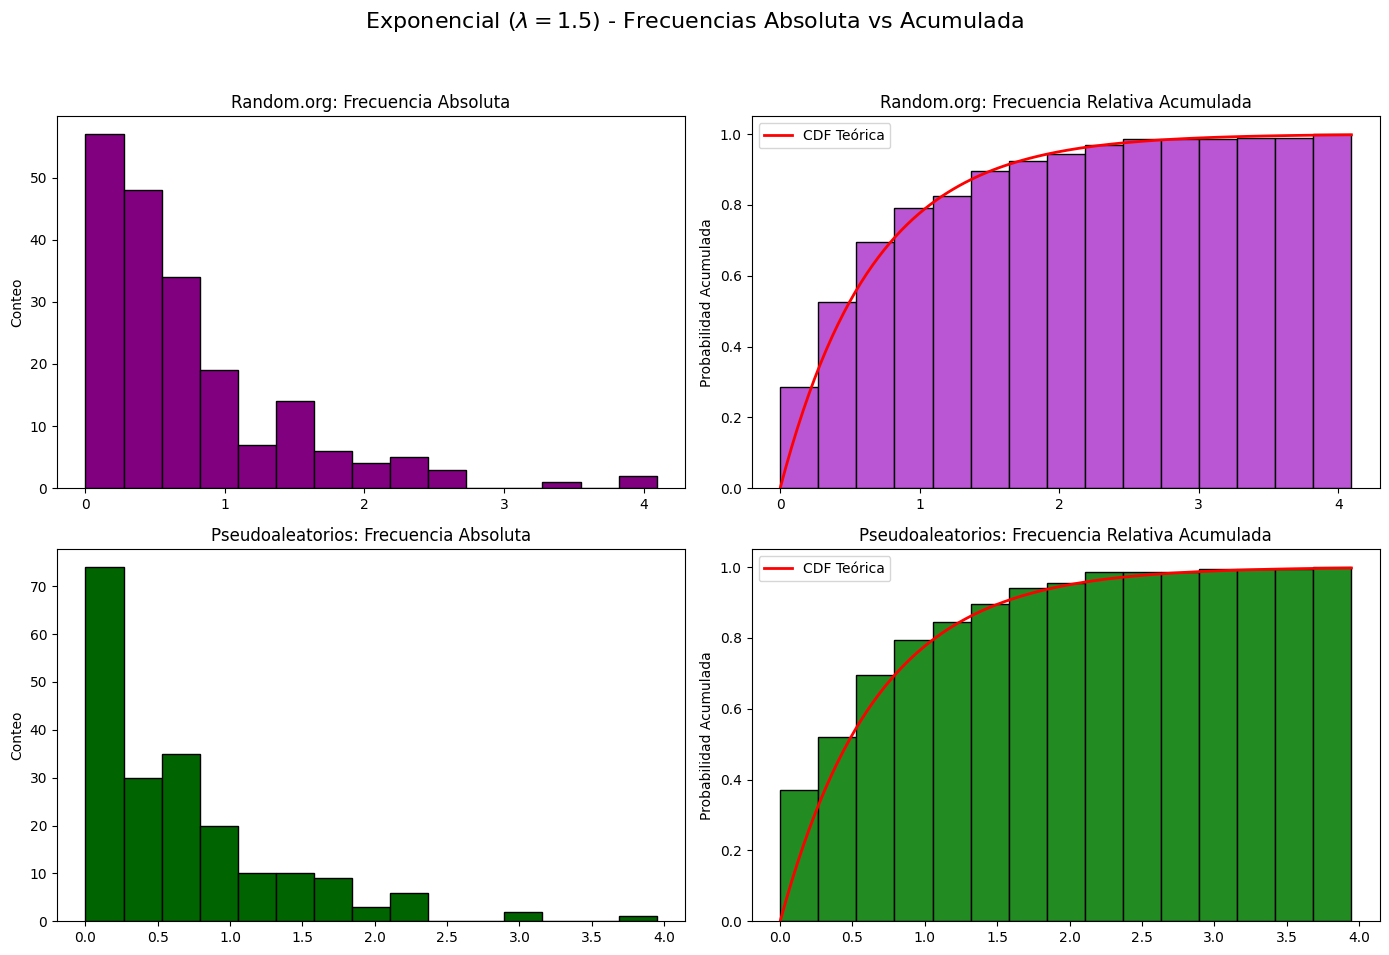


--- GRÁFICOS ADICIONALES (ESTILO DOCENTE, BINS=20, DENSITY=TRUE) ---
Visualizando las distribuciones de la imagen...


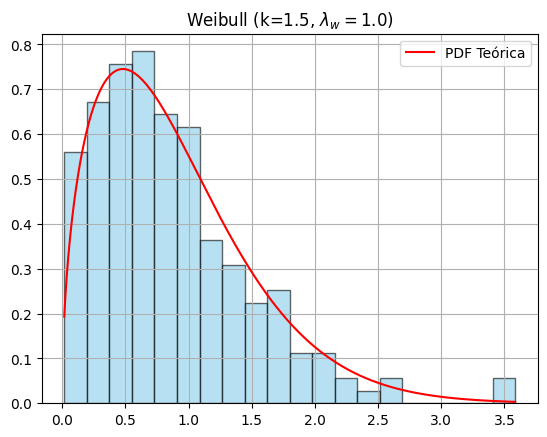

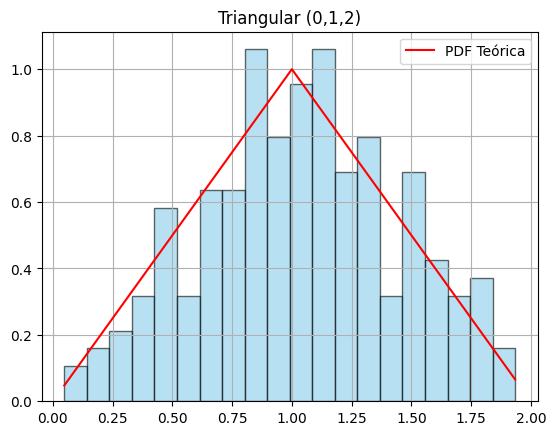

In [10]:
print("--- VISUALIZACIÓN DE RESULTADOS ---")

# --- 1. DEFINICIÓN DE FUNCIONES DE GRAFICADO DEL DOCENTE ---
# Extraído de la imagen: bins=20, density=True
def plot_hist(x, pdf=None, title="", bins_doc=20):
    plt.figure()
    plt.hist(x, bins=bins_doc, density=True, alpha=0.6, color='skyblue', edgecolor='black')
    if pdf:
        xx = np.linspace(min(x), max(x), 2000)
        plt.plot(xx, pdf(xx), 'r', label='PDF Teórica')
        plt.legend()
    plt.title(title)
    plt.grid()
    plt.show()

# --- 2. DEFINICIÓN DE FUNCIONES PDF TEÓRICAS ---
# Extraído de la imagen. Nota: se usan las variables lam_exp, k_w, lam_w, a_unif, b_unif definidas arriba.

def f_exp_teorica(x):
    return lam_exp * np.exp(-lam_exp * x)

def f_unif_teorica(x):
    # Uniforme [3,9] según el título en la imagen
    return np.where((x >= a_unif) & (x <= b_unif), 1 / (b_unif - a_unif), 0)

def f_weib_teorica(x):
    # Fórmula de la imagen: (k/lam_w) * (x/lam_w)**(k-1) * np.exp(-(x/lam_w)**k)
    return (k_w / lam_w) * (x / lam_w)**(k_w - 1) * np.exp(-(x / lam_w)**k_w)

def f_tri_teorica(x):
    # Fórmula de la imagen para triangular (0,1,2)
    # f(x) = x para 0<=x<=1, 2-x para 1<x<=2, 0 en otro caso
    return np.where((x >= 0) & (x <= 1), x, np.where((x > 1) & (x <= 2), 2 - x, 0))


# --- 3. GENERACIÓN DE GRÁFICOS ---

# --- A. TUS REQUERIMIENTOS ORIGINALES PARA LA EXPONENCIAL ---
# Graficamos frecuencia absoluta y frecuencia relativa acumulada

fig_exp, axs_exp = plt.subplots(2, 2, figsize=(14, 10))
fig_exp.suptitle(f'Exponencial ($\lambda = {lam_exp}$) - Frecuencias Absoluta vs Acumulada', fontsize=16)

# Usaremos bins=15 para estas vistas generales
bins_usr = 15

# Fila 1: Random.org (Exponencial)
axs_exp[0, 0].hist(X_exp_ro, bins=bins_usr, color='purple', edgecolor='black')
axs_exp[0, 0].set_title('Random.org: Frecuencia Absoluta')
axs_exp[0, 0].set_ylabel('Conteo')

axs_exp[0, 1].hist(X_exp_ro, bins=bins_usr, color='mediumorchid', edgecolor='black', cumulative=True, density=True)
x_t = np.linspace(0, max(X_exp_ro), 100)
axs_exp[0, 1].plot(x_t, 1 - np.exp(-lam_exp * x_t), color='red', lw=2, label='CDF Teórica')
axs_exp[0, 1].set_title('Random.org: Frecuencia Relativa Acumulada')
axs_exp[0, 1].set_ylabel('Probabilidad Acumulada')
axs_exp[0, 1].legend()

# Fila 2: Pseudoaleatorios (Exponencial)
axs_exp[1, 0].hist(X_exp_ps, bins=bins_usr, color='darkgreen', edgecolor='black')
axs_exp[1, 0].set_title('Pseudoaleatorios: Frecuencia Absoluta')
axs_exp[1, 0].set_ylabel('Conteo')

axs_exp[1, 1].hist(X_exp_ps, bins=bins_usr, color='forestgreen', edgecolor='black', cumulative=True, density=True)
x_t_p = np.linspace(0, max(X_exp_ps), 100)
axs_exp[1, 1].plot(x_t_p, 1 - np.exp(-lam_exp * x_t_p), color='red', lw=2, label='CDF Teórica')
axs_exp[1, 1].set_title('Pseudoaleatorios: Frecuencia Relativa Acumulada')
axs_exp[1, 1].set_ylabel('Probabilidad Acumulada')
axs_exp[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- B. GRÁFICOS SIGUIENDO EL ESTILO DEL DOCENTE ---
# Usando plot_hist, las PDF teóricas, y bins=20.

print("\n--- GRÁFICOS ADICIONALES (ESTILO DOCENTE, BINS=20, DENSITY=TRUE) ---")
print("Visualizando las distribuciones de la imagen...")

# Weibull
plot_hist(X_weib_ro, f_weib_teorica, f"Weibull (k={k_w}, $\lambda_w={lam_w}$)")

# Triangular
plot_hist(X_tri_ro, f_tri_teorica, "Triangular (0,1,2)")